In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
def f(x):
    return 3*x**2 - 4*x + 5

In [11]:
f(3.0)

20.0

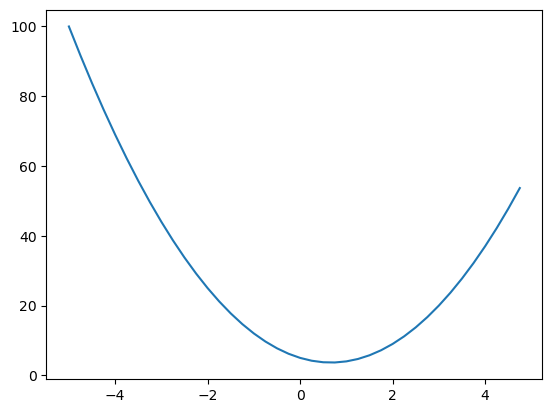

In [12]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.grad = 0.0
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        self._backward = out._backward
        other._backward = out._backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out
    
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a * b + c
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [25]:
d._op

'+'

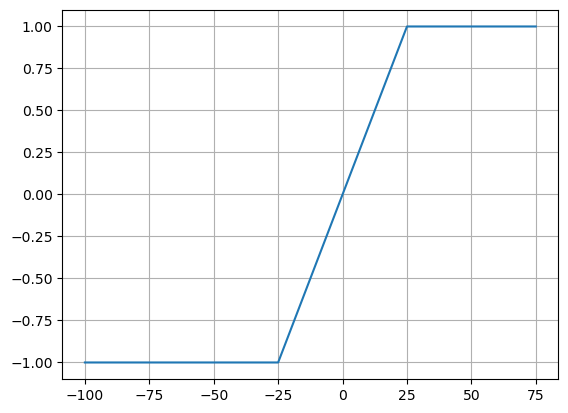

In [32]:
plt.plot(np.arange(-100, 100, 25), np.tanh(np.arange(-100, 100, 25))); plt.grid();

In [45]:
#inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.88137, label='b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
o

Value(data=0.7071049876722272)

In [54]:
o.grad = 1.0 #do/do
n.grad = 1 - o.data**2 #do/dn
b.grad = n.grad * 1.0 #do/db = do/dn * dn/db
x1w1x2w2.grad = n.grad #do/dh = do/dn * dn/dh
x1w1.grad = x1w1x2w2.grad * 1.0 #do/d1 = do/dh * dh/d1
x2w2.grad = x1w1x2w2.grad * 1.0 #do/d2 = do/dh * dh/d2
x1.grad = x1w1.grad * w1.data #do/dx1 = do/d1 * d1/dx1
w1.grad = x1w1.grad * x1.data #do/dw1 = do/d1 * d1/dw1
x2.grad = x2w2.grad * w2.data #do/dx2 = do/d2 * d2/dx2
w2.grad = x2w2.grad * x2.data #do/dw1 = do/d2 * d2/dw2

w1.grad

1.000005072818119